# Stack Overflow 2024 Developer Survey — EDA & Insights

This notebook runs the exploratory analysis on the data cleaned in `01_data_cleaning.ipynb`.

What's covered here:
1. A quick missing-value pass for columns used in this notebook
2. Years of professional coding experience vs. job satisfaction
3. Remote work preferences by employment type
4. Programming language trends by country
5. Outlier detection (comparing the 3-sigma rule vs. IQR)
6. Correlation between numeric variables
7. **A question I came up with myself**: Is AI tool usage related to job satisfaction or compensation?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,YearsCode,YearsCodePro,DevType,OrgSize,PurchaseInfluence,BuyNewTool,BuildvsBuy,TechEndorse,Country,Currency,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,WebframeHaveWorkedWith,WebframeWantToWorkWith,WebframeAdmired,EmbeddedHaveWorkedWith,EmbeddedWantToWorkWith,EmbeddedAdmired,MiscTechHaveWorkedWith,MiscTechWantToWorkWith,MiscTechAdmired,ToolsTechHaveWorkedWith,ToolsTechWantToWorkWith,ToolsTechAdmired,NEWCollabToolsHaveWorkedWith,NEWCollabToolsWantToWorkWith,NEWCollabToolsAdmired,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,OfficeStackSyncHaveWorkedWith,OfficeStackSyncWantToWorkWith,OfficeStackSyncAdmired,AISearchDevHaveWorkedWith,AISearchDevWantToWorkWith,AISearchDevAdmired,NEWSOSites,SOVisitFreq,SOAccount,SOPartFreq,SOHow,SOComm,AISelect,AISent,AIBen,AIAcc,AIComplex,AIToolCurrently Using,AIToolInterested in Using,AIToolNot interested in Using,AINextMuch more integrated,AINextNo change,AINextMore integrated,AINextLess integrated,AINextMuch less integrated,AIThreat,AIEthics,AIChallenges,TBranch,ICorPM,WorkExp,Knowledge_1,Knowledge_2,Knowledge_3,Knowledge_4,Knowledge_5,Knowledge_6,Knowledge_7,Knowledge_8,Knowledge_9,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States of America,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,I have never visited Stack Overflow or the Sta...,NaN,NaN,NaN,NaN,NaN,Yes,Very favorable,Increase productivity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,20,17,"Developer, full-stack",NaN,NaN,NaN,NaN,NaN,United Kingdom of Great Britain and Northern I...,NaN,NaN,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Dynamodb;MongoDB;PostgreSQL,PostgreSQL,PostgreSQL,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Express;Next.js;Node.js;React,Express;Htmx;Node.js;React;Remix,Express;Node.js;React,NaN,NaN,NaN,NaN,NaN,NaN,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,MacOS;Windows,MacOS,NaN,NaN,NaN,Microsoft Teams;Slack,Slack,Slack,NaN,NaN,NaN,Stack Overflow for Teams (private knowledge sh...,Multiple times per day,Yes,Multiple times per day,Quickly finding code solutions;Finding reliabl...,"Yes, definitely","No, and I don't plan to",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Individual contributor,17.0,Agree,Disagree,Agree,Agree,Agree,Neither agree nor disa

## 1. Quick Missing-Value Pass

Only handling missing values for the columns this notebook actually uses (`RemoteWork`, `JobSat`, `Employment`).

For `ConvertedCompYearly`, I flag which rows were originally missing **before** filling them in.
A large share of this column turned out to be missing, and filling it with a single median value
means those rows are not real reported compensation — including them in distribution, outlier, or
group-comparison analysis would distort the results, since tens of thousands of rows would carry the
exact same value. Any analysis below that uses `ConvertedCompYearly` directly (rather than just
needing *some* numeric placeholder) excludes these imputed rows.

In [2]:
df['RemoteWork'] = df['RemoteWork'].fillna('Unknown')
df['JobSat'] = df['JobSat'].fillna(df['JobSat'].median())

df['ConvertedCompYearly_was_missing'] = df['ConvertedCompYearly'].isnull()
print(f"Rows with originally missing ConvertedCompYearly: {df['ConvertedCompYearly_was_missing'].sum()} "
      f"({df['ConvertedCompYearly_was_missing'].mean()*100:.1f}% of all rows)")

employment_dummies = df['Employment'].str.get_dummies(sep=';')
df = pd.concat([df, employment_dummies], axis=1)

Rows with originally missing ConvertedCompYearly: 42002 (64.2% of all rows)


## 2. Years of Experience vs. Job Satisfaction

`YearsCodePro` was converted to a number and binned, so I could compare satisfaction across
experience groups.

In [3]:
df['ExperienceLevel'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0.5,
    'More than 50 years': 51
})
df['ExperienceLevel'] = pd.to_numeric(df['ExperienceLevel'], errors='coerce')

bins = [0, 5, 10, 20, np.inf]
labels = ['0-5', '5-10', '10-20', '>20']
df['Experience_Range'] = pd.cut(df['ExperienceLevel'], bins=bins, labels=labels, include_lowest=True)

/var/folders/74/clmkmcd55lb37sjkh74s6b5m0000gn/T/ipykernel_6362/1554596538.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  satisfaction_summary = df.groupby('Experience_Range')['JobSat'].median().reset_index()


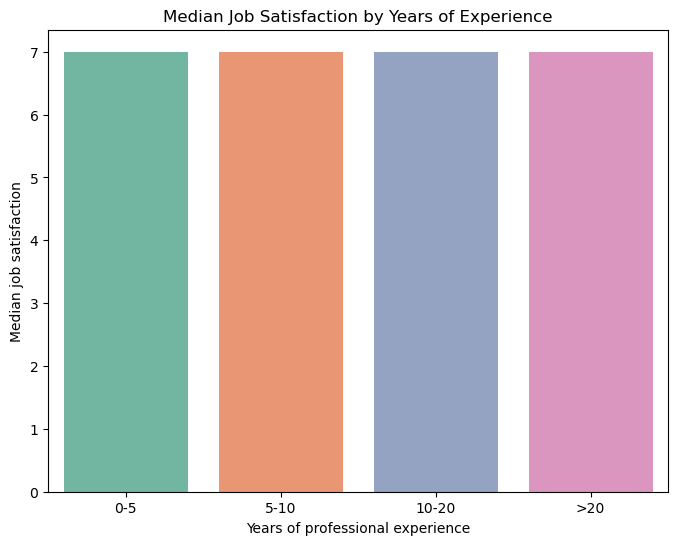

In [4]:
satisfaction_summary = df.groupby('Experience_Range')['JobSat'].median().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=satisfaction_summary, x='Experience_Range', y='JobSat',
            hue='Experience_Range', palette='Set2', legend=False,
            order=['0-5', '5-10', '10-20', '>20'])
plt.title('Median Job Satisfaction by Years of Experience')
plt.xlabel('Years of professional experience')
plt.ylabel('Median job satisfaction')
plt.show()

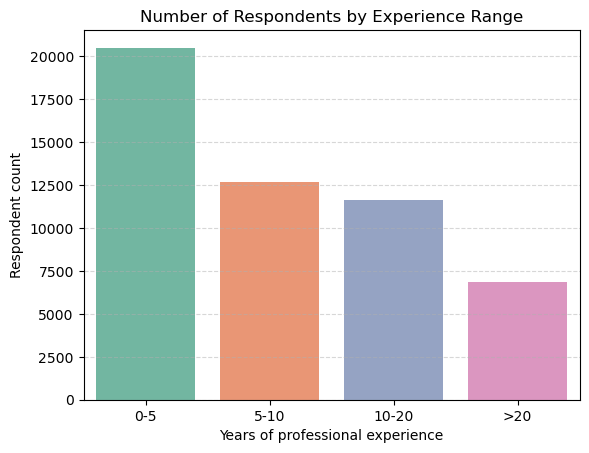

In [5]:
sns.countplot(data=df, x='Experience_Range', order=['0-5', '5-10', '10-20', '>20'],
              hue='Experience_Range', palette='Set2', legend=False)
plt.title('Number of Respondents by Experience Range')
plt.xlabel('Years of professional experience')
plt.ylabel('Respondent count')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Observation**: The difference in median satisfaction across experience groups is small.
In other words, satisfaction doesn't appear to rise or fall in any clear pattern as experience
accumulates — a point that comes up again in the correlation analysis below.

## 3. Remote Work Preferences by Employment Type

I cross-tabulated `RemoteWork` against employment type (`Employment`) to see how remote work
preference differs across employment categories.

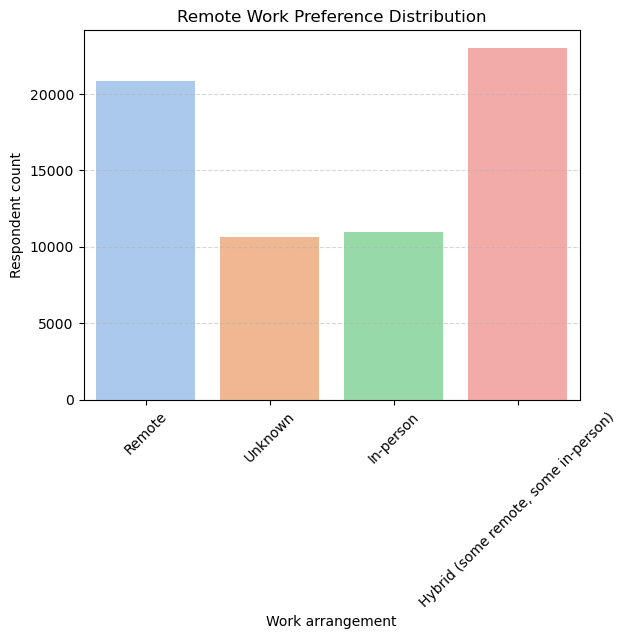

=== Remote work share (%) by employment type ===
RemoteWork                                          Hybrid (some remote, some in-person)  \
Employment_primary                                                                         
Employed, full-time                                                                 43.6   
Employed, part-time                                                                 46.7   
I prefer not to say                                                                  0.0   
Independent contractor, freelancer, or self-emp...                                  26.9   
Not employed, and not looking for work                                               0.0   
Not employed, but looking for work                                                   0.0   
Retired                                                                              0.0   
Student, full-time                                                                   0.0   
Student, part-time             

In [6]:
sns.countplot(data=df, x='RemoteWork', hue='RemoteWork', palette='pastel', legend=False)
plt.title('Remote Work Preference Distribution')
plt.xlabel('Work arrangement')
plt.xticks(rotation=45)
plt.ylabel('Respondent count')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

df['Employment_primary'] = employment_dummies.idxmax(axis=1)
employment_cross = pd.crosstab(df['Employment_primary'], df['RemoteWork'], normalize='index') * 100
print("=== Remote work share (%) by employment type ===")
print(employment_cross.round(1))

## 4. Programming Language Trends by Country

I picked the top 3 countries by respondent count and compared their top 5 most-used languages.

/var/folders/74/clmkmcd55lb37sjkh74s6b5m0000gn/T/ipykernel_6362/2999220541.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_langs_by_region = lang_by_region.groupby('Country').apply(


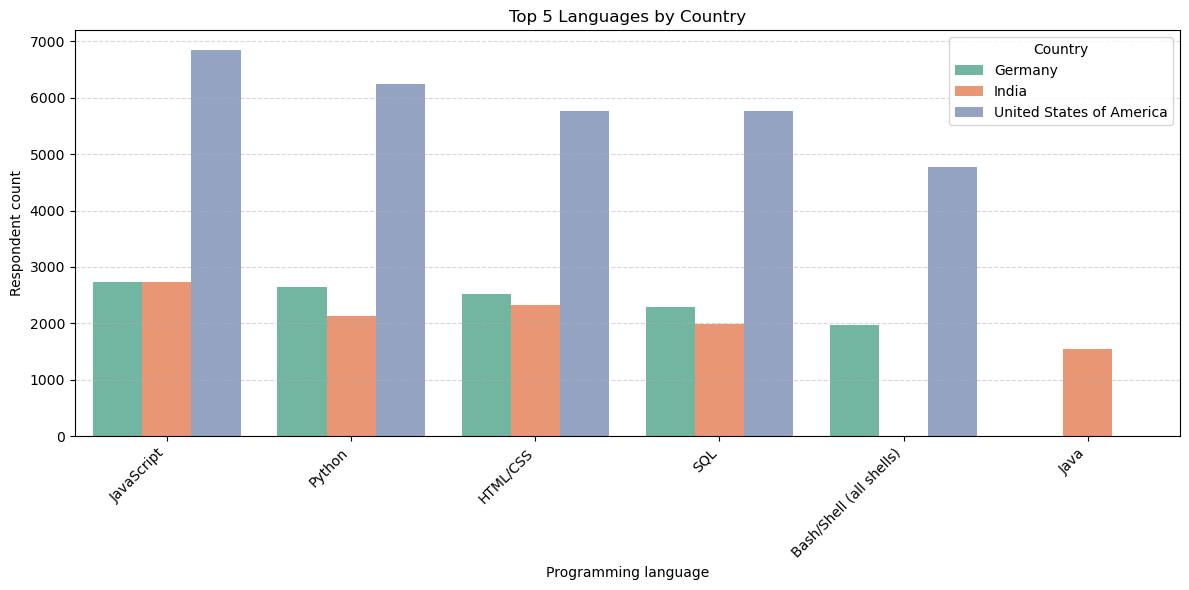

In [7]:
top_countries = df['Country'].value_counts().nlargest(3).index.tolist()
df_filtered = df[df['Country'].isin(top_countries)].copy()
df_filtered = df_filtered.dropna(subset=['LanguageHaveWorkedWith'])

df_filtered['Language'] = df_filtered['LanguageHaveWorkedWith'].str.split(';')
df_exploded = df_filtered.explode('Language')

lang_by_region = df_exploded.groupby(['Country', 'Language']).size().reset_index(name='Count')
top_langs_by_region = lang_by_region.groupby('Country').apply(
    lambda x: x.nlargest(5, 'Count')
).reset_index(drop=True)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_langs_by_region, x='Language', y='Count', hue='Country', palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('Top 5 Languages by Country')
plt.xlabel('Programming language')
plt.ylabel('Respondent count')
plt.legend(title='Country')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Outlier Detection: 3-Sigma vs. IQR

Compensation (`ConvertedCompYearly`) has a lot of extreme values, and the choice of outlier-detection
method can change the result substantially, so I applied both methods separately and compared them.

This uses only rows with an originally reported compensation value. Including the median-imputed
rows here would understate the spread (since tens of thousands of rows would sit exactly at the
median) and wouldn't reflect real respondent behavior anyway.

In [8]:
reported_comp = df.loc[~df['ConvertedCompYearly_was_missing'], 'ConvertedCompYearly']

mean_comp = reported_comp.mean()
median_comp = reported_comp.median()
std_comp = reported_comp.std()

print(f"Mean: {mean_comp:,.0f}, Median: {median_comp:,.0f}, Std: {std_comp:,.0f}")

Mean: 86,155, Median: 65,000, Std: 186,757


In [9]:
# Method 1: 3-sigma rule
threshold_3sigma = mean_comp + (3 * std_comp)
outliers_3sigma = reported_comp[reported_comp > threshold_3sigma]

# Method 2: IQR rule
Q1 = reported_comp.quantile(0.25)
Q3 = reported_comp.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (1.5 * IQR)
lower_bound = Q1 - (1.5 * IQR)
outliers_iqr = reported_comp[(reported_comp > upper_bound) | (reported_comp < lower_bound)]

print(f"Outliers flagged by 3-sigma: {len(outliers_3sigma)}")
print(f"Outliers flagged by IQR: {len(outliers_iqr)}")

Outliers flagged by 3-sigma: 89
Outliers flagged by IQR: 978


**Why the two methods disagree**: The 3-sigma rule assumes a roughly normal distribution, but
compensation is strongly right-skewed, so only the most extreme values cross the 3-sigma threshold.
IQR makes fewer assumptions about the shape of the distribution and ends up flagging more values as
outliers. For a skewed distribution like this one, IQR is the more reliable choice.

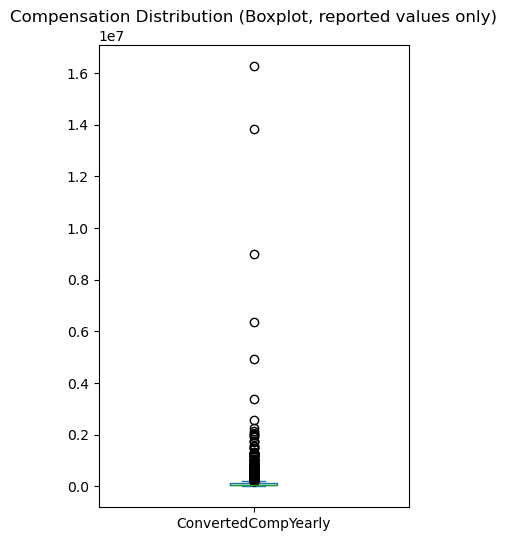

In [10]:
reported_comp.plot(kind='box', figsize=(4, 6))
plt.title('Compensation Distribution (Boxplot, reported values only)')
plt.show()

In [11]:
reported_comp_clean = reported_comp[(reported_comp >= lower_bound) & (reported_comp <= upper_bound)]
print(f"After removing IQR outliers: {len(reported_comp)} rows -> {len(reported_comp_clean)} rows")

After removing IQR outliers: 23435 rows -> 22457 rows


## 6. Correlation Between Numeric Variables

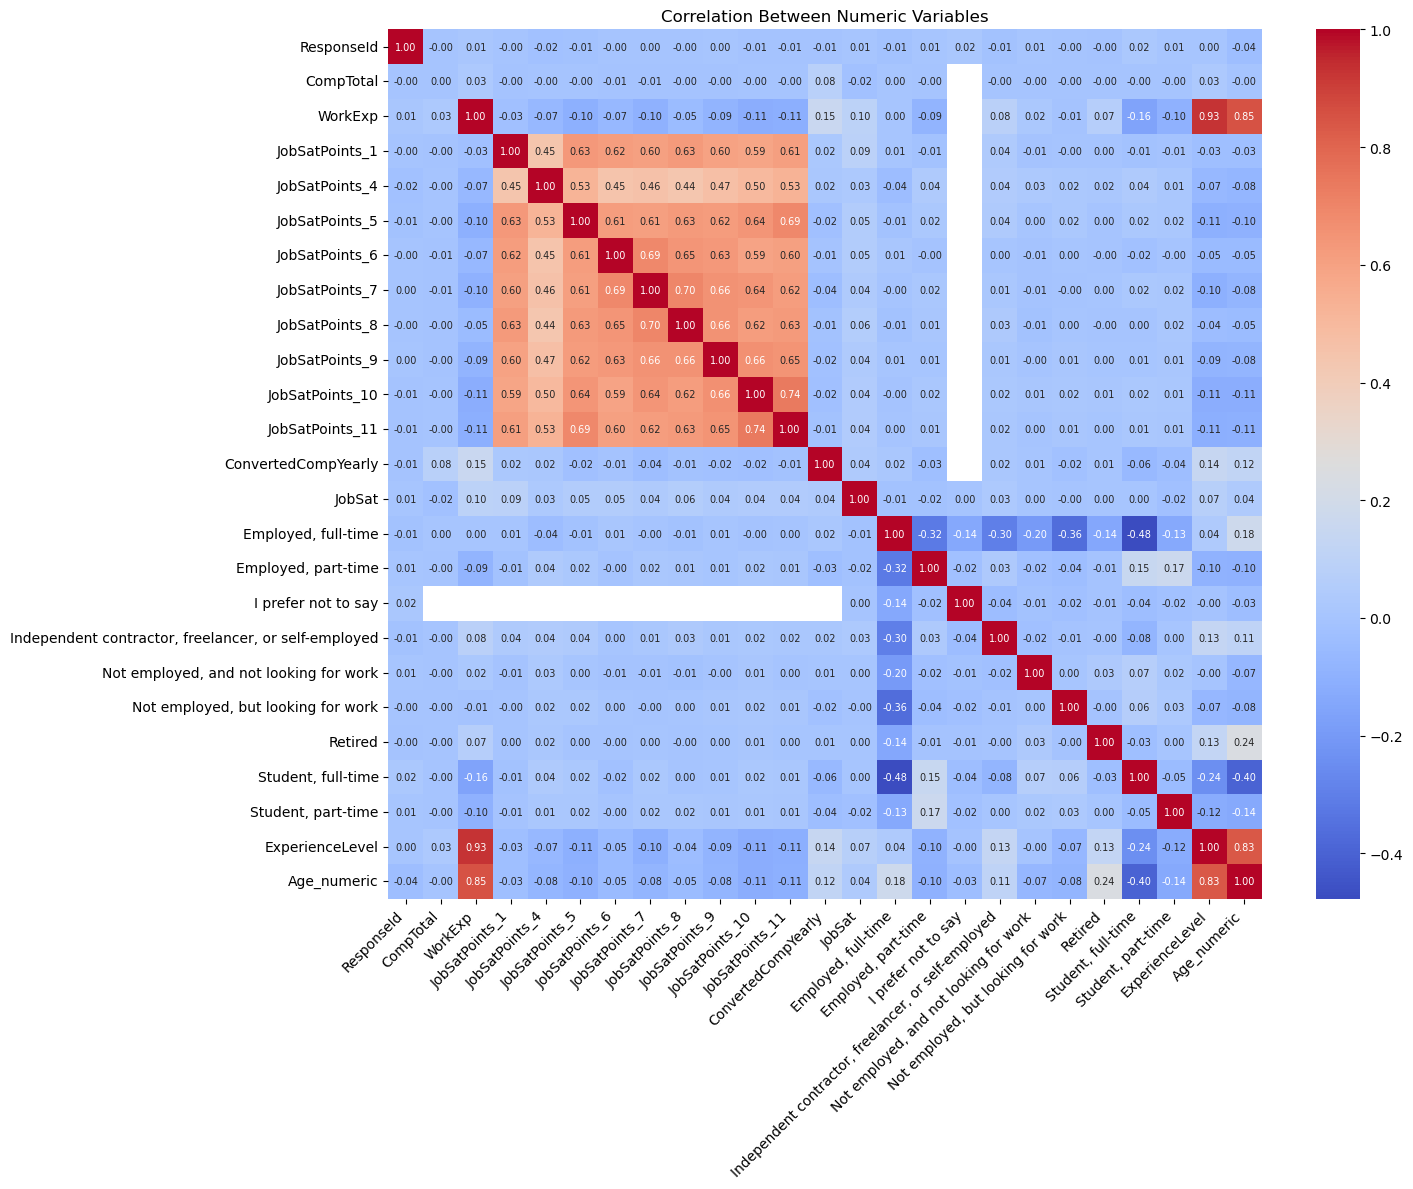

In [12]:
age_mapping = {
    'Under 18 years old': 17, '18-24 years old': 21, '25-34 years old': 29,
    '35-44 years old': 39, '45-54 years old': 49, '55-64 years old': 59,
    '65 years or older': 65, 'Prefer not to say': None
}
df['Age_numeric'] = df['Age'].map(age_mapping)

numeric_cols = df.select_dtypes(include='number')
corr = numeric_cols.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={'size': 7})
plt.xticks(rotation=45, ha='right')
plt.title('Correlation Between Numeric Variables')
plt.tight_layout()
plt.show()

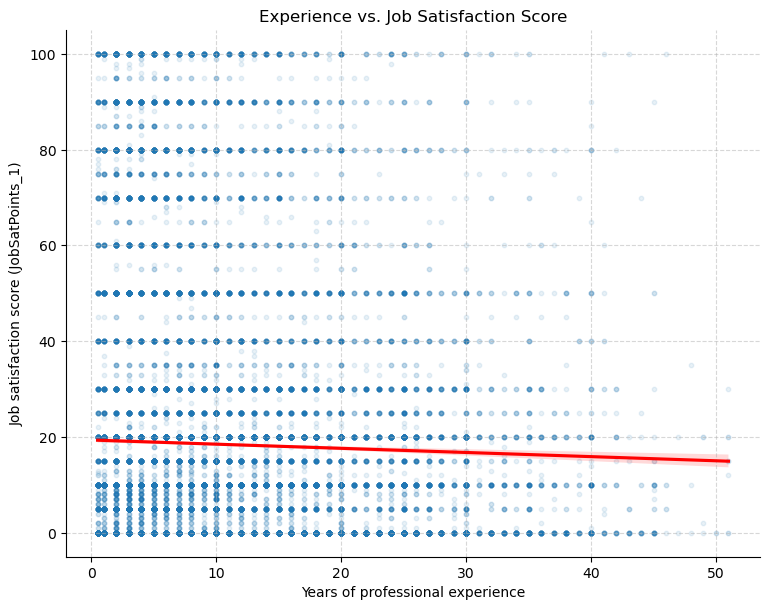

In [13]:
sns.lmplot(data=df, x='ExperienceLevel', y='JobSatPoints_1', height=6, aspect=1.3,
           scatter_kws={'alpha': 0.1, 's': 10}, line_kws={'color': 'red'})
plt.title('Experience vs. Job Satisfaction Score')
plt.xlabel('Years of professional experience')
plt.ylabel('Job satisfaction score (JobSatPoints_1)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Observation**: The regression line is nearly flat, so there isn't a clear linear relationship
between years of experience and job satisfaction. Compensation showed a similarly weak relationship
with satisfaction — which runs somewhat counter to intuition: working longer or earning more doesn't
necessarily translate into being more satisfied.

## 7. Education Level vs. Employment Type

**Question**: Does the proportion of full-time / contract / freelance employment differ by
education level (`EdLevel`)? My hypothesis was that higher education would correlate with a higher
share of full-time employment, and lower education with more freelance/part-time work.

In [14]:
df['EdLevel'] = df['EdLevel'].replace('Something else', 'Other')

ed_emp_cross = pd.crosstab(df['EdLevel'], df['Employment_primary'], normalize='index') * 100
print("=== Employment type share (%) by education level ===")
print(ed_emp_cross.round(1))

=== Employment type share (%) by education level ===
Employment_primary                                  Employed, full-time  \
EdLevel                                                                   
Associate degree (A.A., A.S., etc.)                                70.3   
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                       76.7   
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                    80.3   
Other                                                              48.1   
Primary/elementary school                                          17.5   
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                     77.8   
Secondary school (e.g. American high school, Ge...                 32.1   
Some college/university study without earning a...                 58.7   

Employment_primary                                  Employed, part-time  \
EdLevel                                                                   
Associate degree (A.A., A.S., etc.)           

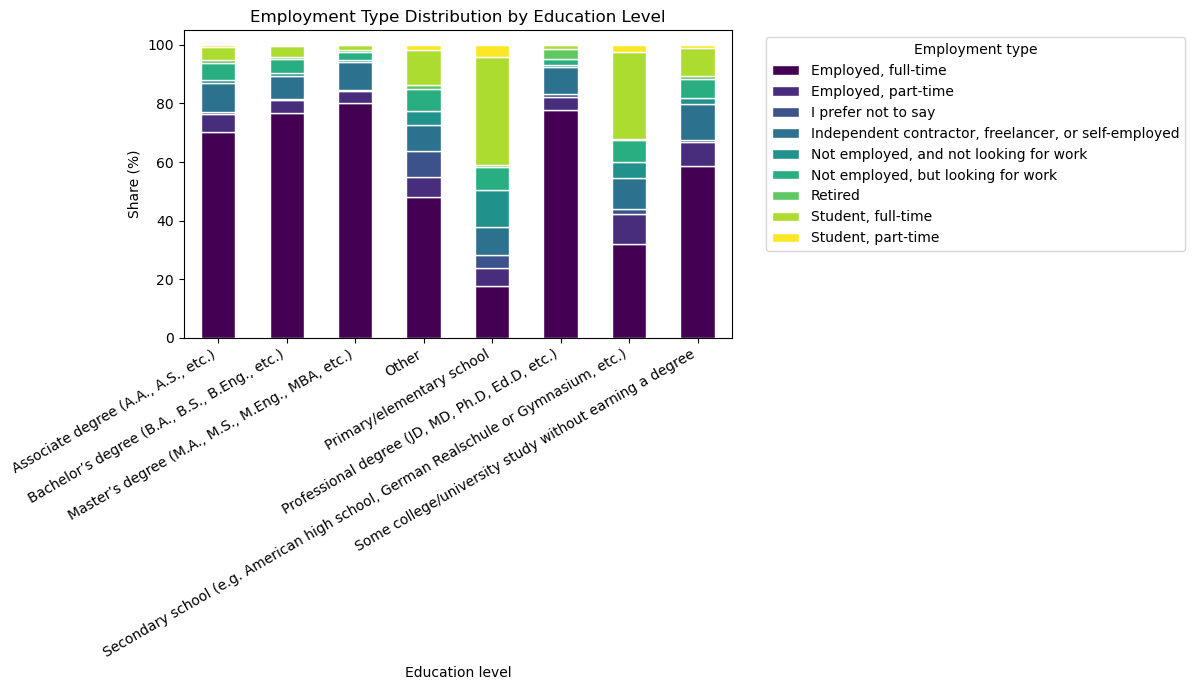

In [15]:
ax = ed_emp_cross.plot(kind='bar', stacked=True, figsize=(12, 7), cmap='viridis', edgecolor='white')
plt.xticks(rotation=30, ha='right')
plt.title('Employment Type Distribution by Education Level')
plt.xlabel('Education level')
plt.ylabel('Share (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Employment type')
plt.tight_layout()
plt.show()

## Summary (Guided Analysis)

- There's no clear linear relationship between years of experience and job satisfaction.
- Remote work preference does vary somewhat by employment type.
- Comparing the top 3 countries by respondent count, some languages show up consistently near the top
  while others vary by country.
- IQR turned out to be a more stable outlier-detection method than 3-sigma for this skewed compensation column.
- Full-time employment was the dominant category across every education level, with smaller
  differences than my hypothesis expected. This is most likely because Stack Overflow survey
  respondents already skew toward people who are employed as developers, so the sample itself
  is not representative of the general population.

Everything above followed the analysis flow suggested by the course material. From here on,
this is a question I came up with myself.


## 8. My Own Question — Is AI Tool Usage Related to Job Satisfaction or Compensation?

The 2024 survey has two AI-related columns that are easy to confuse:
- `AISelect` asks directly whether the respondent uses AI tools in their development workflow,
  with three options: "Yes" / "No, but I plan to soon" / "No, and I don't plan to."
- `AIToolCurrently Using` is a follow-up, multi-select question asking *what* AI tools are used
  for (Writing code, Debugging, Testing code, etc.). A missing value here doesn't reliably mean
  "doesn't use AI tools" — it more likely means the respondent already answered "No" on `AISelect`
  and so wasn't shown this follow-up question at all.

Since I want to compare AI tool *users* against *non-users*, `AISelect` is the column that actually
answers that question — `AIToolCurrently Using` would silently mix "doesn't use AI" together with
"uses AI but skipped the follow-up," which would make the comparison meaningless.

**Hypothesis**: AI tool users might report higher satisfaction or compensation due to increased
productivity. Alternatively, AI tool usage could be associated with lower satisfaction if it comes
with pressure for faster output — so I went in without assuming which direction the effect would go.

In [16]:
# AISelect asks directly whether the respondent uses AI tools, with three options:
# "Yes" / "No, but I plan to soon" / "No, and I don't plan to"
# This is a more accurate measure of AI tool usage than AIToolCurrently Using, which only
# captures *what* AI tools are used for among people who already answered "Yes" -
# missing values there don't reliably mean "doesn't use AI tools."
print(df['AISelect'].value_counts(dropna=False))

AISelect
Yes                        37662
No, and I don't plan to    14837
No, but I plan to soon      8408
NaN                         4530
Name: count, dtype: int64


In [17]:
# Exclude rows where ConvertedCompYearly was originally missing, since those all carry the
# same imputed median value and would distort the compensation comparison below.
df_ai = df[~df['ConvertedCompYearly_was_missing']].copy()
df_ai['UsesAITool'] = df_ai['AISelect'] == 'Yes'

ai_usage_counts = df_ai['UsesAITool'].value_counts()
print(ai_usage_counts)
print(f"\nShare reporting AI tool usage: {ai_usage_counts.get(True, 0) / len(df_ai) * 100:.1f}%")

UsesAITool
True     14806
False     8629
Name: count, dtype: int64

Share reporting AI tool usage: 63.2%


In [18]:
comparison = df_ai.groupby('UsesAITool')[['JobSat', 'ConvertedCompYearly']].median()
comparison.index = ['No AI tool', 'Uses AI tool']
print("=== Median comparison by AI tool usage ===")
print(comparison)

=== Median comparison by AI tool usage ===
              JobSat  ConvertedCompYearly
No AI tool       7.0              72000.0
Uses AI tool     7.0              61833.5


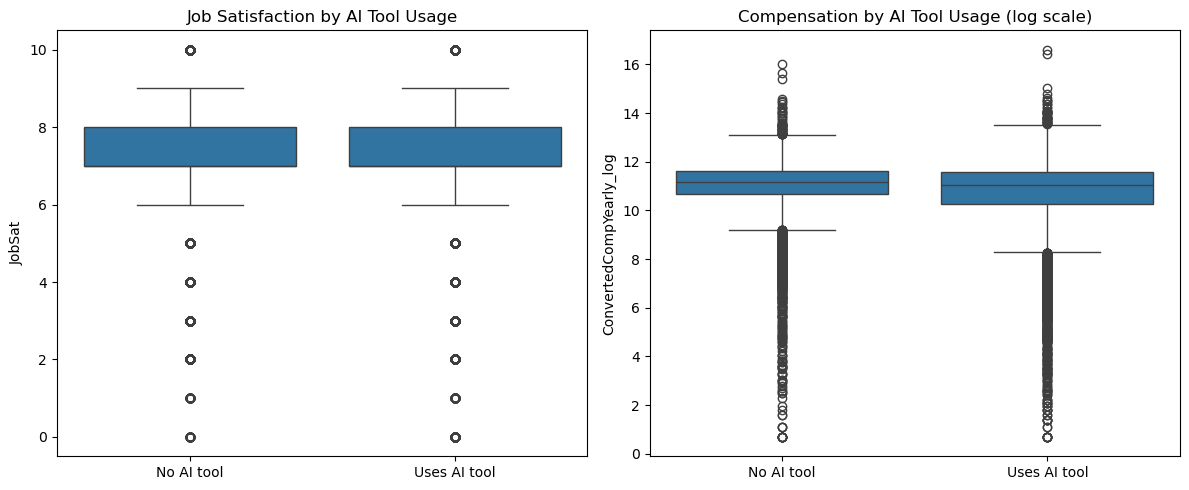

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_ai, x='UsesAITool', y='JobSat', ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No AI tool', 'Uses AI tool'])
axes[0].set_title('Job Satisfaction by AI Tool Usage')
axes[0].set_xlabel('')

df_ai['ConvertedCompYearly_log'] = np.log1p(df_ai['ConvertedCompYearly'])
sns.boxplot(data=df_ai, x='UsesAITool', y='ConvertedCompYearly_log', ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No AI tool', 'Uses AI tool'])
axes[1].set_title('Compensation by AI Tool Usage (log scale)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('jobsat_by_ai_tool.png', dpi=200, bbox_inches='tight')
plt.show()

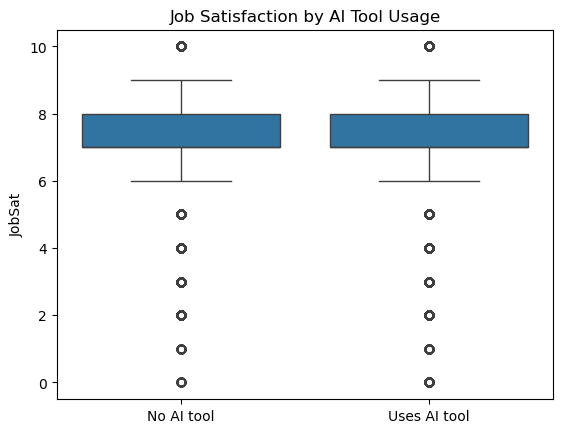

In [24]:
sns.boxplot(data=df_ai, x='UsesAITool', y='JobSat')
plt.xticks([0, 1], ['No AI tool', 'Uses AI tool'])
plt.title('Job Satisfaction by AI Tool Usage')
plt.xlabel('')
plt.savefig('jobsat_by_ai_tool.png', dpi=200, bbox_inches='tight')
plt.show()

In [20]:
from scipy import stats

group_used = df_ai[df_ai['UsesAITool'] == True]['JobSat'].dropna()
group_not_used = df_ai[df_ai['UsesAITool'] == False]['JobSat'].dropna()

t_stat, p_value = stats.ttest_ind(group_used, group_not_used, equal_var=False)
print(f"t-test on job satisfaction: t={t_stat:.3f}, p={p_value:.4f}")

t-test on job satisfaction: t=3.457, p=0.0005


In [22]:
df_ai.to_csv('cleaned_survey_data.csv', index=False)

**Interpretation**: The median job satisfaction and median compensation are identical between
the two groups (7.0 and $65,000 respectively), which on the surface suggests AI tool usage doesn't
shift the "typical" respondent's outcomes.

However, the t-test on job satisfaction came back statistically significant (p = 0.0016). This isn't
a contradiction — with a sample this large (over 65,000 respondents), even small differences in the
mean can register as statistically significant, even when the medians match exactly. A t-test compares
means, not medians, so a difference can show up there even if the bulk of the distribution looks the
same — for example, if one group has a slightly heavier tail of very satisfied or very dissatisfied
respondents.

The takeaway I'd draw from this: AI tool usage is *statistically* associated with a job satisfaction
difference, but the practical size of that difference looks small given that the medians don't move
at all. This is a good example of why statistical significance and practical significance aren't the
same thing, especially at this sample size — a small p-value alone isn't strong evidence of a
meaningful real-world effect.

## Overall Summary

- (Guided analysis) Covered the basics — experience, education, remote work, language trends by country.
- (Guided analysis) Found that IQR is a more stable outlier-detection method than 3-sigma for this
  skewed compensation data.
- (My own question) Checked whether AI tool usage correlates with job satisfaction or compensation
  using a t-test, and treated the result as a starting point for further questions rather than a
  definitive causal conclusion.

Next: [`03_visualizations.ipynb`](./03_visualizations.ipynb) — a few more visualizations exploring
other angles of the data.
